# Imports

In [375]:
import sklearn
from sklearn.model_selection import train_test_split

In [376]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datasets


## Real world dataset


Load the real world dataset and display the structure

In [377]:


''' dataset = sklearn.datasets.fetch_california_housing( return_X_y=False, as_frame=False) '''

' dataset = sklearn.datasets.fetch_california_housing( return_X_y=False, as_frame=False) '

In [378]:
''' print(dataset.data[0]) '''

' print(dataset.data[0]) '

In [379]:
''' print(dataset.target) '''

' print(dataset.target) '

## Synthetic dataset


In [380]:
def generate_synthetic_data(n_samples=200, n_features=20, noise=5.0, seed=42):
    np.random.seed(seed)

    # Create correlated features
    X = np.random.randn(n_samples, n_features)

    # Introduce correlation (important for ridge usefulness)
    X[:, 1] = X[:, 0] + 0.01 * np.random.randn(n_samples)
    X[:, 2] = X[:, 0] - 0.01 * np.random.randn(n_samples)

    # True weights (sparse-ish)
    true_w = np.zeros(n_features)
    true_w[:5] = [5, -3, 2, 0, 1]

    # Generate targets
    y = X @ true_w + noise * np.random.randn(n_samples)

    return X, y, true_w

# Data augmentation

Create a random permuntation so I can make sure that the model works and not only with single permuntation

In [381]:
def loadRealData():
  dataset = sklearn.datasets.load_diabetes( return_X_y=False, as_frame=False)
  X = dataset.data
  Y = dataset.target
  return X, Y

In [382]:
#set seed for this to be reproducible
def assingPermuntation(X, Y, seed = 42):
  np.random.seed(seed)

  n = X.shape[0]
  perm = np.random.permutation(n)

  X = X[perm]
  Y = Y[perm]
  return X, Y

In [383]:
''' print(X[0]) '''

' print(X[0]) '

Create the training, test split

In [384]:
def trainSplit(X, Y):
   X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
   return X_train, X_test, y_train, y_test


In [385]:
''' X_train.shape, y_train.shape
 '''

' X_train.shape, y_train.shape\n '

In [386]:
''' X_test.shape, y_test.shape '''

' X_test.shape, y_test.shape '

The trouble I ran into was the dataset not being expressive enough, so I'm creating polynomial features

In [387]:
# Adding more features, x^^2
def polySquared(X_tr, X_te):
  X_train = np.c_[X_tr, X_tr**2]
  X_test = np.c_[X_te, X_te**2]
  return X_train, X_test



Add a bias (intercept) to the datapoints so the weights are not being updated that harshly

In [388]:
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]



# helper functions

Determine simple functions

In [389]:
#Error

def calculcateError( label, predi):
  predictionError = ( predi - label ) ** 2
  ''' print( predictionError) '''
  return predictionError


def sumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = calculcateError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError


# Non squared error
def simpleError( label, predi):
  predictionError =  predi - label
  ''' print( predictionError) '''
  return predictionError




# Non squared error
def simpleSumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = simpleError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError

#Mean squared error
def mse(y_pred, y):
    return np.mean((y_pred - y) ** 2)


# crude and easy implementation of a prediction
def predict(X, w):
    return X @ w


In [390]:

def getFeatureBlame( X, y, y_pred):

    # figure out how each feature contributed to those errors
    return (X.T @ (y_pred - y))

Ridge specific helpers

In [391]:
# ridge addon for weights
def getRidgePenalty(alpha, w):
    total = 0
    for i in range(len(w)):
      total += (w[i] ** 2)


    return alpha * total


def getRidgeGradient(alpha, w):

  reg = 2 * alpha * w
  reg[0] = 0
  return reg

# Ridge model

In [392]:
# L2, ridge
def ridge(X, y, alpha = 1, lR = 0.001, epochs = 10000):


  prev_loss = float("inf")


  m, n = X.shape

  # Create weights
  w = np.zeros(n)

  for i in range(epochs):
    y_pred = predict(X, w)


    ''' loss  = sumError(y_pred, y) '''
    loss = mse(y_pred, y) + alpha * np.sum(w[1:]**2)
    # Drop learning rate if we see no  development
    ''' if loss >= prev_loss:
      lR *= 0.8
    prev_loss = loss '''

    gradient = (2 / m) *  getFeatureBlame(X, y ,y_pred) + getRidgeGradient(alpha, w)
    '''   print(gradient) '''
    # update weights
    w = w - lR * gradient


    ''' print(w ) '''
  return w

## Lets find good weights


Fiddleling around with alpha and learning rate to find a good candidate or in a way "fitting" the model. Takes aprox 2min

In [393]:
def fitRidge(X_train, X_test, y_train, y_test, epochs= 1000):
  best_mse = float("inf")
  best_alpha = None
  best_lr = None
  best_w = None

  for alpha in [ 1e-4, 1e-3, 1e-2, 1e-1]:
    for lr in [  1e-4 , 1e-3, 1e-2]:

      w = ridge(  X_train, y_train, alpha=alpha, lR=lr, epochs = epochs)
      pred = predict(X_test, w)
      current_mse = mse(pred, y_test)
      print("alpha: ", alpha,"lr: ", lr,"mse: ", current_mse)

      # Look if the score is worse or same
      if current_mse < best_mse:
        # Update best variables
        best_mse = current_mse
        best_alpha = alpha
        best_lr = lr
        best_w = w

    print("alpha:", alpha, "||w||:", np.linalg.norm(w))
  print("\nBEST RESULT:")
  print("alpha:", best_alpha, "lr:", best_lr, "mse:", best_mse)

  return best_w

## Training

## Real world dataset

In [394]:
X_real, Y_real = loadRealData()
X_real, Y_real = assingPermuntation(X_real, Y_real, seed = 42)


X_real_train, X_real_test, y_real_train, y_real_test  = trainSplit(X_real, Y_real)

X_real_train = add_bias(X_real_train)
X_real_test = add_bias(X_real_test)


# Retrieve ridge weights from a crude implementation
best_real_w = fitRidge(X_real_train, X_real_test, y_real_train, y_real_test, epochs = 20000)
testPredictions = predict(X_real_test, best_real_w)
print(sumError(testPredictions, y_real_test))

mse_test = mse(y_real_test, testPredictions)
rmse_test = np.sqrt(mse_test)
print(mse_test, rmse_test)

alpha:  0.0001 lr:  0.0001 mse:  4229.048922905416
alpha:  0.0001 lr:  0.001 mse:  3497.553589050949
alpha:  0.0001 lr:  0.01 mse:  2551.8212519538242
alpha: 0.0001 ||w||: 657.3730917002105
alpha:  0.001 lr:  0.0001 mse:  4229.279169825393
alpha:  0.001 lr:  0.001 mse:  3510.407565731133
alpha:  0.001 lr:  0.01 mse:  2561.2678609767904
alpha: 0.001 ||w||: 590.4415104231281
alpha:  0.01 lr:  0.0001 mse:  4231.5521775024945
alpha:  0.01 lr:  0.001 mse:  3628.2094132214042
alpha:  0.01 lr:  0.01 mse:  3082.817318199765
alpha: 0.01 ||w||: 307.14410584325026
alpha:  0.1 lr:  0.0001 mse:  4251.598108036598
alpha:  0.1 lr:  0.001 mse:  4149.049858492819
alpha:  0.1 lr:  0.01 mse:  4145.495424803228
alpha: 0.1 ||w||: 160.84867129785485

BEST RESULT:
alpha: 0.0001 lr: 0.01 mse: 2551.8212519538242
227112.09142389035
2551.8212519538242 50.51555455455106


In [395]:
for i in range(10):
  print("Error for " + str(i)
        + ": " + str(calculcateError(testPredictions[i], y_real_test[i]))
        + ", Prediction: " + str(testPredictions[i])
        + ", label : " +str( y_real_test[i]))

Error for 0: 140.76947499365812, Prediction: 152.86463126243956, label : 141.0
Error for 1: 4050.8191162885173, Prediction: 172.64604556677907, label : 109.0
Error for 2: 2423.973770975048, Prediction: 231.76613187068227, label : 281.0
Error for 3: 255.2421212139744, Prediction: 247.02370126675223, label : 263.0
Error for 4: 7777.626486632784, Prediction: 149.1908526244802, label : 61.0
Error for 5: 708.5539781243084, Prediction: 173.38132275780202, label : 200.0
Error for 6: 12515.071454067891, Prediction: 180.1292198379403, label : 292.0
Error for 7: 5499.698403287844, Prediction: 147.15995147846203, label : 73.0
Error for 8: 48.998111440913426, Prediction: 89.99986510162256, label : 83.0
Error for 9: 2130.65745014929, Prediction: 162.15904516071893, label : 116.0


In [396]:
print(best_real_w)

[ 153.20714369   14.99216097  -65.47985217  391.37094991  234.61174361
   -6.9161659   -55.0653981  -202.65052304  145.34372332  335.65641313
  134.17672943]


 ### Visualization

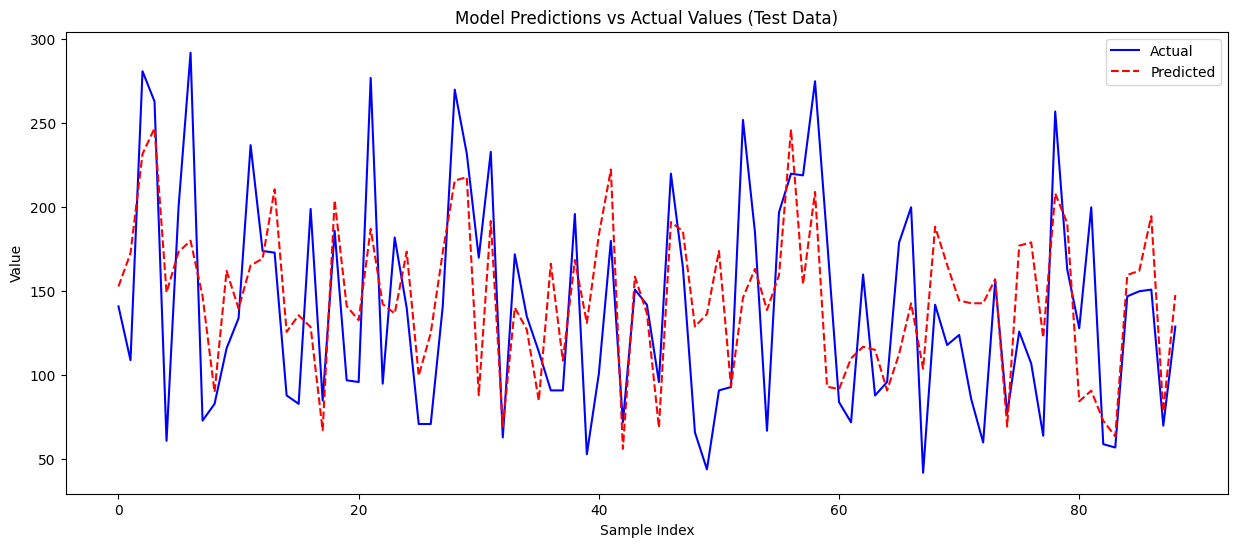

In [397]:
num_samples_to_plot = len(X_real_test)
indices = np.arange(num_samples_to_plot)

plt.figure(figsize=(15, 6))
plt.plot(indices, y_real_test[:num_samples_to_plot], 'b-', label='Actual')
plt.plot(indices, testPredictions[:num_samples_to_plot], 'r--', label='Predicted')
plt.title('Model Predictions vs Actual Values (Test Data)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.show()

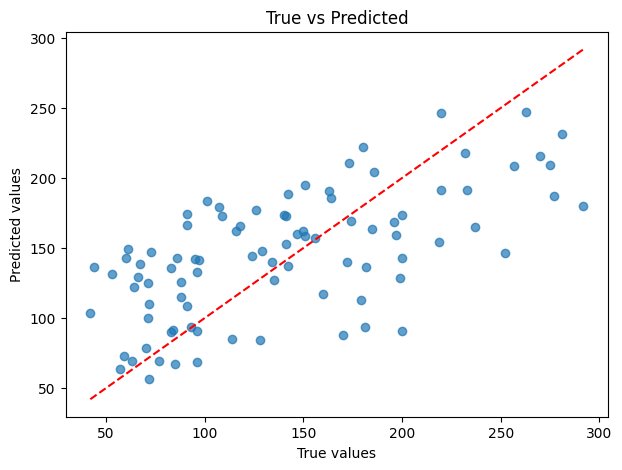

In [398]:
plt.figure(figsize=(7, 5))
plt.scatter(y_real_test, testPredictions, alpha=0.7)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")

min_val = min(y_real_test.min(), testPredictions.min())
max_val = max(y_real_test.max(), testPredictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.show()

## Synthetic dataset


In [399]:
X_synt, Y_synt, synth_true_w = generate_synthetic_data(n_samples=120, n_features=80, noise=15.0, seed=42)
X_synt, Y_synt = assingPermuntation(X_synt, Y_synt, seed = 42)
X_synt_train, X_synt_test, y_synt_train, y_synt_test  = trainSplit(X_synt, Y_synt)

# Add bias so we're not completely lost
X_synt_train = add_bias(X_synt_train)
X_synt_test = add_bias(X_synt_test)

# Retrieve ridge weights from a crude implementation
best_synt_w = fitRidge(X_synt_train, X_synt_test, y_synt_train, y_synt_test, epochs = 20000)

# Last test predictions
testPredictions = predict(X_synt_test, best_synt_w)
print(sumError(testPredictions, y_synt_test))



mse_test = mse(y_synt_test, testPredictions)
rmse_test = np.sqrt(mse_test)
print(mse_test, rmse_test)

alpha:  0.0001 lr:  0.0001 mse:  249.82791044712494
alpha:  0.0001 lr:  0.001 mse:  404.3063842273914
alpha:  0.0001 lr:  0.01 mse:  1105.2023646048935
alpha: 0.0001 ||w||: 34.17553613511191
alpha:  0.001 lr:  0.0001 mse:  249.70376506489777
alpha:  0.001 lr:  0.001 mse:  398.8469345709746
alpha:  0.001 lr:  0.01 mse:  978.4130162403059
alpha: 0.001 ||w||: 32.36833875377673
alpha:  0.01 lr:  0.0001 mse:  248.48852625339293
alpha:  0.01 lr:  0.001 mse:  354.06482330223974
alpha:  0.01 lr:  0.01 mse:  492.8624727380143
alpha: 0.01 ||w||: 23.836847377184625
alpha:  0.1 lr:  0.0001 mse:  238.5848429808287
alpha:  0.1 lr:  0.001 mse:  241.69691109851473
alpha:  0.1 lr:  0.01 mse:  241.84001729296565
alpha: 0.1 ||w||: 13.71589199636468

BEST RESULT:
alpha: 0.1 lr: 0.0001 mse: 238.5848429808287
5726.036231539888
238.5848429808287 15.446191860158565


In [400]:
for i in range(10):
  print("Error for " + str(i)
        + ": " + str(calculcateError(testPredictions[i], y_synt_test[i]))
        + ", Prediction: " + str(testPredictions[i])
        + ", label : " +str( y_synt_test[i]))

Error for 0: 3.258756648835642, Prediction: -19.42257857489412, label : -17.617375913463654
Error for 1: 213.14690809964867, Prediction: 2.8281386808956985, label : -11.77141295946808
Error for 2: 45.573792529819585, Prediction: 11.022990267664797, label : 4.272153835798033
Error for 3: 25.91336231255036, Prediction: -8.738938469838871, label : -13.829455370169363
Error for 4: 3.342097688275595, Prediction: 11.243585529180766, label : 9.415445029034348
Error for 5: 9.532911574579376, Prediction: -10.452019013318663, label : -7.364477665485508
Error for 6: 87.8541321498101, Prediction: 3.3892346715707613, label : -5.9838188410157365
Error for 7: 415.0092840762869, Prediction: -9.033703667164389, label : 11.338072987714954
Error for 8: 911.8130951435497, Prediction: -3.1721171841031923, label : 27.024125879290466
Error for 9: 69.53493723806903, Prediction: 12.117928651653788, label : 3.7791675183637214


### Visualization


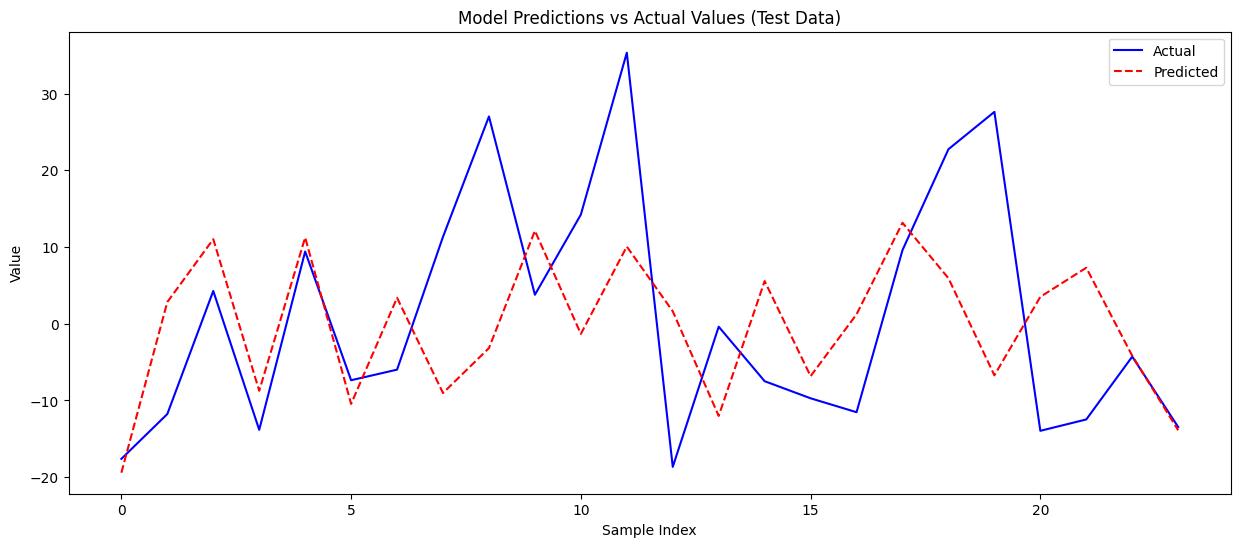

In [401]:
num_samples_to_plot = len(X_synt_test)
indices = np.arange(num_samples_to_plot)

plt.figure(figsize=(15, 6))
plt.plot(indices, y_synt_test[:num_samples_to_plot], 'b-', label='Actual')
plt.plot(indices, testPredictions[:num_samples_to_plot], 'r--', label='Predicted')
plt.title('Model Predictions vs Actual Values (Test Data)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.show()

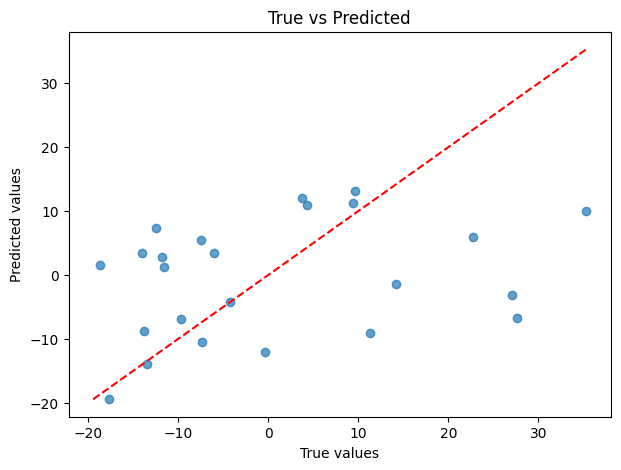

In [402]:
plt.figure(figsize=(7, 5))
plt.scatter(y_synt_test, testPredictions, alpha=0.7)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")

min_val = min(y_synt_test.min(), testPredictions.min())
max_val = max(y_synt_test.max(), testPredictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.show()

# Testing generilization
